In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error , r2_score
import matplotlib.pyplot as plt


In [5]:
data=pd.read_csv("data.csv")
data.head()


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,02/05/2014,313000.0,3,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,02/05/2014,2384000.0,5,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,02/05/2014,342000.0,3,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,02/05/2014,420000.0,3,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,02/05/2014,550000.0,4,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [6]:
X = data[["bedrooms","bathrooms","sqft_living","floors","condition", "waterfront", "view", "yr_built"]]
y= data["price"]
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)


In [7]:
model=LinearRegression()
model.fit(X_train, y_train)
y_pred=model.predict(X_test)

In [8]:
print("R2 scores", r2_score(y_test, y_pred))
print("MAE", mean_absolute_error(y_test, y_pred))
print("MSE", mean_squared_error(y_test, y_pred))
print("Intercept", model.intercept_)

R2 scores 0.030785588817155096
MAE 212096.8085764086
MSE 988449770004.282
Intercept 5169988.203358445


In [9]:
new_house = pd.DataFrame({
    'bedrooms':[3],
    'bathrooms':[3],
    'sqft_living':[2600],
    'floors':[2],
    'condition':[3],
    'waterfront':[0],
    'view':[1],
    'yr_built':[9],
})
predicted_price=model.predict(new_house)
print("Predicted Value: ",predicted_price)

Predicted Value:  [6046689.9790091]


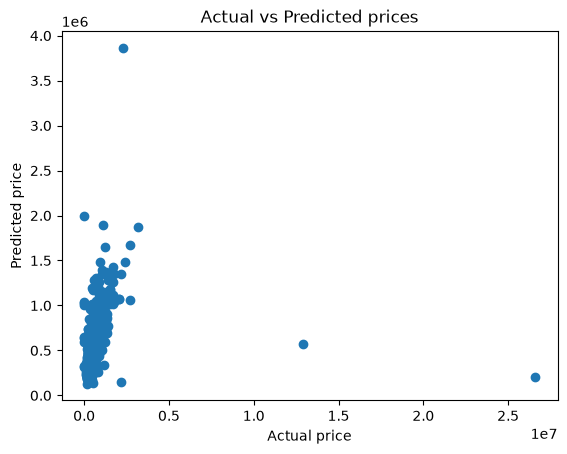

In [10]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Actual vs Predicted prices")
plt.show()
